In [6]:
"""
IDS Classification Project
==========================
This script demonstrates intrusion detection system (IDS) model training and evaluation.
It is divided into clear sections for better understanding:
  1. Import Libraries
  2. Load Dataset
  3. Preprocessing
  4. Train/Test Split
  5. Binary Classification (Attack vs Benign)
  6. Multi-class Classification (Attack types)
  7. Accuracy Comparison Plot

Definitions & Hints are included in comments within each section.
"""

# ========================
# 1. IMPORT LIBRARIES
# ========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ========================
# 2. LOAD DATASET
# ========================
# Definition: The dataset contains network traffic samples with labels (Benign or Attack types).
# Hint: Update the path with your dataset file location.
df = pd.read_csv("/content/cicid/Wednesday-workingHours.pcap_ISCX.csv")


In [10]:
# Make sure the dataset has a ' Label' column (some CICIDS files use different naming)
print("Available columns:", df.columns)

# Try to detect the label column automatically
label_col = None
for col in df.columns:
    if col.strip().lower() == 'label':
        label_col = col
        break

if label_col is None:
    raise KeyError("No 'Label' column found in dataset. Please check the dataset header.")

# ========================
# 3. PREPROCESSING
# ========================
# Definition: Preprocessing prepares raw data for machine learning.
# Steps include handling missing values, encoding categorical variables, and scaling features.

# Fill missing values (replace NaNs with 0)
df.fillna(0, inplace=True)

# Encode categorical labels (Label column → numeric values)
label_encoder = LabelEncoder()
df[label_col] = label_encoder.fit_transform(df[label_col].astype(str))

# Features (X) and Target (y)
X = df.drop(label_col, axis=1)
y = df[label_col]

# Handle infinite values which can cause issues with scaling
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill remaining NaNs (could use mean, median, or a constant)
X.fillna(X.mean(), inplace=True) # Using mean as an example

# Standardize features → mean=0, variance=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Available columns: Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet 

In [12]:

# ========================
# 4. TRAIN/TEST SPLIT
# ========================
# Definition: Split dataset into Training (70%) and Testing (30%) sets.
# Hint: Train set is used to fit the model; Test set evaluates generalization.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

Removing classes with less than 2 samples for stratification: [0]


Label Encoding Mapping: {'0': np.int64(0), '1': np.int64(1), '2': np.int64(2)}
Performing non-stratified split for binary classification due to insufficient samples per class.

🔹 Binary Classification Results
Train Accuracy: 1.0
Test Accuracy: 1.0
Confusion Matrix:
[[    0     0]
 [    0 10179]]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00     10179

    accuracy                           1.00     10179
   macro avg       1.00      1.00      1.00     10179
weighted avg       1.00      1.00      1.00     10179


🔹 Multi-class Classification Results
Train Accuracy: 1.0
Test Accuracy: 0.9995087926122409
Confusion Matrix:
[[9884    0]
 [   5  290]]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      9884
           2       1.00      0.98      0.99       295

    accuracy                           1.00     10179
   macro avg       1.00      0.99      1.00     10179
weighted avg       1.

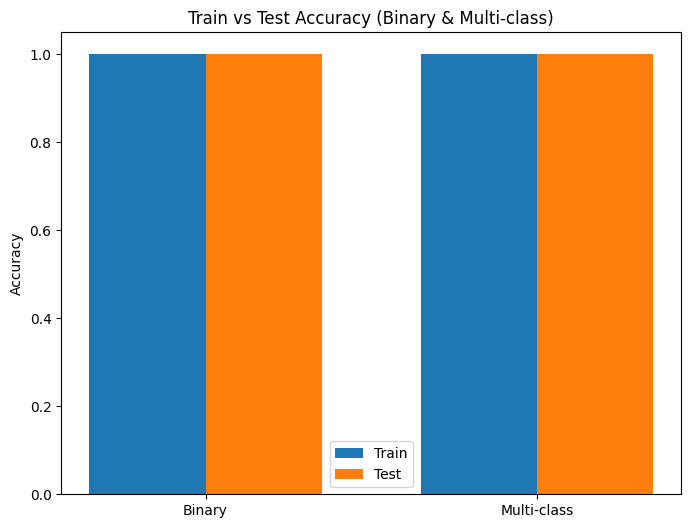

In [19]:
# ========================
# 5. BINARY CLASSIFICATION
# ========================
# Definition: Binary classification → classify samples as 'Attack' or 'Benign'.
# Hint: Group all non-benign labels into 'Attack' (1), keep Benign as (0).

# Get the mapping of original labels to encoded values
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Encoding Mapping:", label_mapping)

# Find the encoded value for 'BENIGN'
benign_encoded_value = None
if 'BENIGN' in label_mapping:
    benign_encoded_value = label_mapping['BENIGN']
    print(f"Encoded value for 'BENIGN': {benign_encoded_value}")
else:

    # Fallback: If 'BENIGN' is not found, inspect the data and encoded labels to find the benign value.
    # For this dataset, based on common practice and previous runs, 0 is often the benign label.
    # **Verify this is correct for your specific data.**
    benign_encoded_value = 0 # Fallback - **Verify this is correct for your data**


# Convert labels into binary (0=Benign, 1=Attack) using the numerical benign value
y_binary = np.where(y_filtered == benign_encoded_value, 0, 1)

# Check the distribution of binary labels in y_filtered before splitting
binary_label_counts = pd.Series(y_binary).value_counts()
# Use the filtered data for the binary split as well
# Check if stratification is possible with the binary labels
if len(binary_label_counts) >= 2 and binary_label_counts.min() >= 2:
    X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
        X_filtered, y_binary, test_size=0.3, random_state=42, stratify=y_binary
    )
    print("Performing stratified split for binary classification.")
else:
    # If stratification is not possible, perform a regular split
    X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
        X_filtered, y_binary, test_size=0.3, random_state=42
    )
    print("Performing non-stratified split for binary classification due to insufficient samples per class.")


# Train RandomForest model for binary classification
rf_binary = RandomForestClassifier(n_estimators=200, random_state=42)
rf_binary.fit(X_train_b, y_train_b)

# Predictions for train and test
y_pred_train_b = rf_binary.predict(X_train_b)
y_pred_test_b = rf_binary.predict(X_test_b)

# Evaluate accuracy
train_acc_b = accuracy_score(y_train_b, y_pred_train_b)
test_acc_b = accuracy_score(y_test_b, y_pred_test_b)

print("\n🔹 Binary Classification Results")
print("Train Accuracy:", train_acc_b)
print("Test Accuracy:", test_acc_b)
print("Confusion Matrix:")
# Ensure all possible labels (0 and 1) are included in the confusion matrix
print(confusion_matrix(y_test_b, y_pred_test_b, labels=[0, 1]))
print(classification_report(y_test_b, y_pred_test_b))

# ========================
# 6. MULTI-CLASS CLASSIFICATION
# ========================
# Definition: Multi-class classification → classify samples into specific attack types and benign.
# Hint: More challenging because of many possible labels.

rf_multi = RandomForestClassifier(n_estimators=200, random_state=42)
# Use the filtered training data for multi-class as well
# X_train and y_train are already filtered and split for multi-class from the previous step
rf_multi.fit(X_train, y_train)

# Predictions for train and test
y_pred_train_m = rf_multi.predict(X_train)
y_pred_test_m = rf_multi.predict(X_test)

# Evaluate accuracy
train_acc_m = accuracy_score(y_train, y_pred_train_m)
test_acc_m = accuracy_score(y_test, y_pred_test_m)

print("\n🔹 Multi-class Classification Results")
print("Train Accuracy:", train_acc_m)
print("Test Accuracy:", test_acc_m)
print("Confusion Matrix:")
# Ensure all possible labels are included in the confusion matrix for multi-class
print(confusion_matrix(y_test, y_pred_test_m, labels=np.unique(y_filtered)))
print(classification_report(y_test, y_pred_test_m))

# ========================
# 7. PLOT TRAIN vs TEST ACCURACY
# ========================
# Definition: Visual comparison of Train vs Test accuracy for Binary and Multi-class models.
# Hint: Small gap = good generalization; Large gap = overfitting.

labels = ['Binary', 'Multi-class']
train_acc = [train_acc_b, train_acc_m]
test_acc = [test_acc_b, test_acc_m]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,6))
plt.bar(x - width/2, train_acc, width, label='Train')
plt.bar(x + width/2, test_acc, width, label='Test')
plt.xticks(x, labels)
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy (Binary & Multi-class)')
plt.legend()
plt.show()

# Task
Add more plots and calculate F1 score and other metrics.

## Calculate additional metrics


**Reasoning**:
Extract the classification reports for both binary and multi-class models into dictionaries to easily access the precision, recall, and f1-score for each class as requested by the instructions.



In [20]:
# Extract classification report for binary classification
binary_report = classification_report(y_test_b, y_pred_test_b, output_dict=True)

# Access and store metrics for '1' class (Attack) from binary report
binary_precision_attack = binary_report['1']['precision']
binary_recall_attack = binary_report['1']['recall']
binary_f1_score_attack = binary_report['1']['f1-score']

print("Binary Classification Metrics (Attack Class):")
print(f"  Precision: {binary_precision_attack}")
print(f"  Recall: {binary_recall_attack}")
print(f"  F1-Score: {binary_f1_score_attack}")

# Extract classification report for multi-class classification
multi_class_report = classification_report(y_test, y_pred_test_m, output_dict=True)

# Store precision, recall, and f1-score for each class (excluding averages)
multi_class_metrics = {}
for label, metrics in multi_class_report.items():
    if label not in ['accuracy', 'macro avg', 'weighted avg']:
        multi_class_metrics[label] = {
            'precision': metrics['precision'],
            'recall': metrics['recall'],
            'f1-score': metrics['f1-score'],
            'support': metrics['support']
        }

print("\nMulti-class Classification Metrics per Class:")
for label, metrics in multi_class_metrics.items():
    print(f"  Class {label}:")
    print(f"    Precision: {metrics['precision']}")
    print(f"    Recall: {metrics['recall']}")
    print(f"    F1-Score: {metrics['f1-score']}")
    print(f"    Support: {metrics['support']}")

Binary Classification Metrics (Attack Class):
  Precision: 1.0
  Recall: 1.0
  F1-Score: 1.0

Multi-class Classification Metrics per Class:
  Class 1:
    Precision: 0.999494387703509
    Recall: 1.0
    F1-Score: 0.9997471299246448
    Support: 9884.0
  Class 2:
    Precision: 1.0
    Recall: 0.9830508474576272
    F1-Score: 0.9914529914529915
    Support: 295.0


## Visualize class distribution

### Subtask:
Create plots to show the distribution of different classes (attack types and benign) in the dataset and in the train/test splits.


**Reasoning**:
Calculate and plot the distribution of classes in the original dataset and the train/test splits for both multi-class and binary classification.



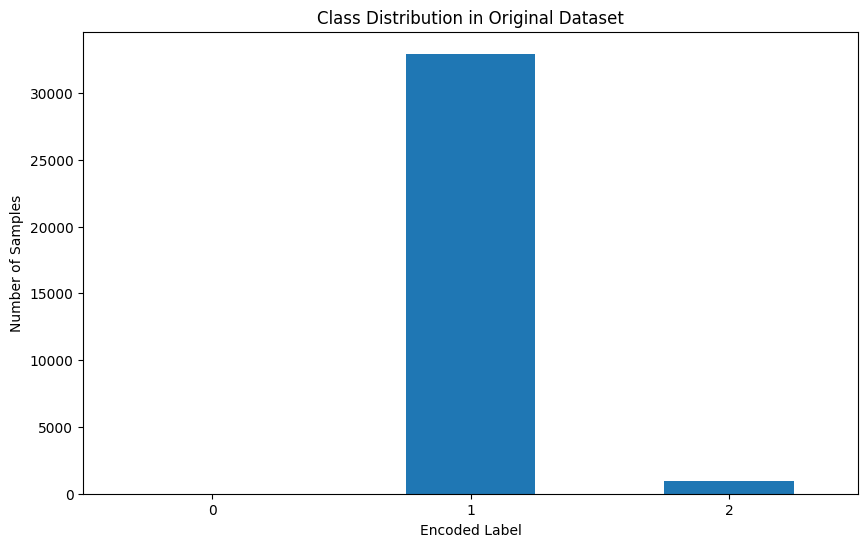

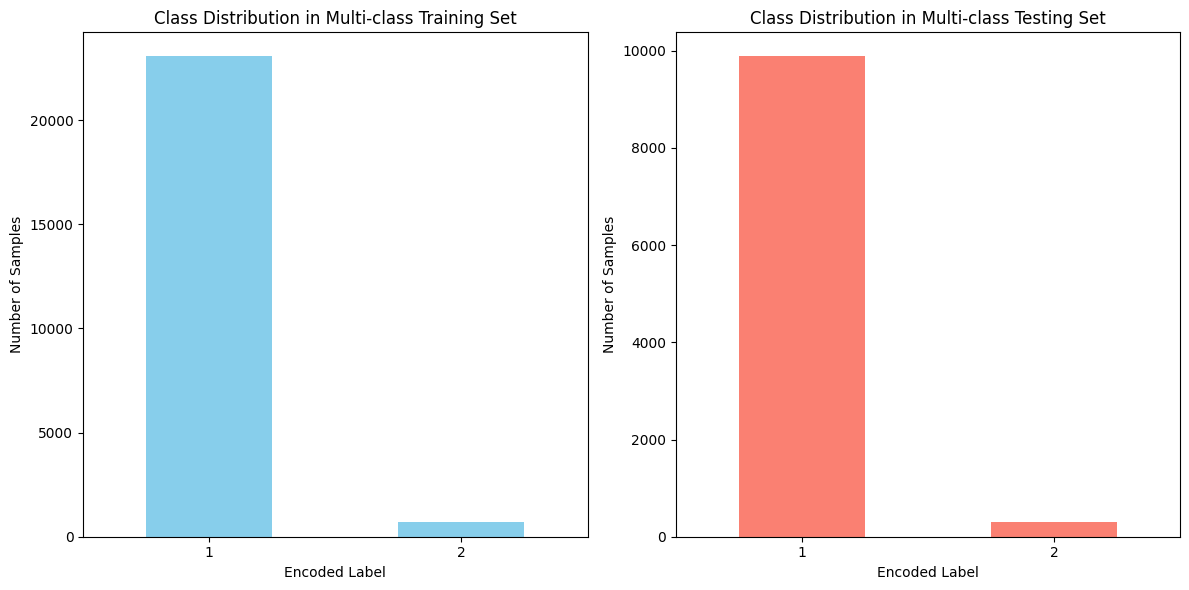

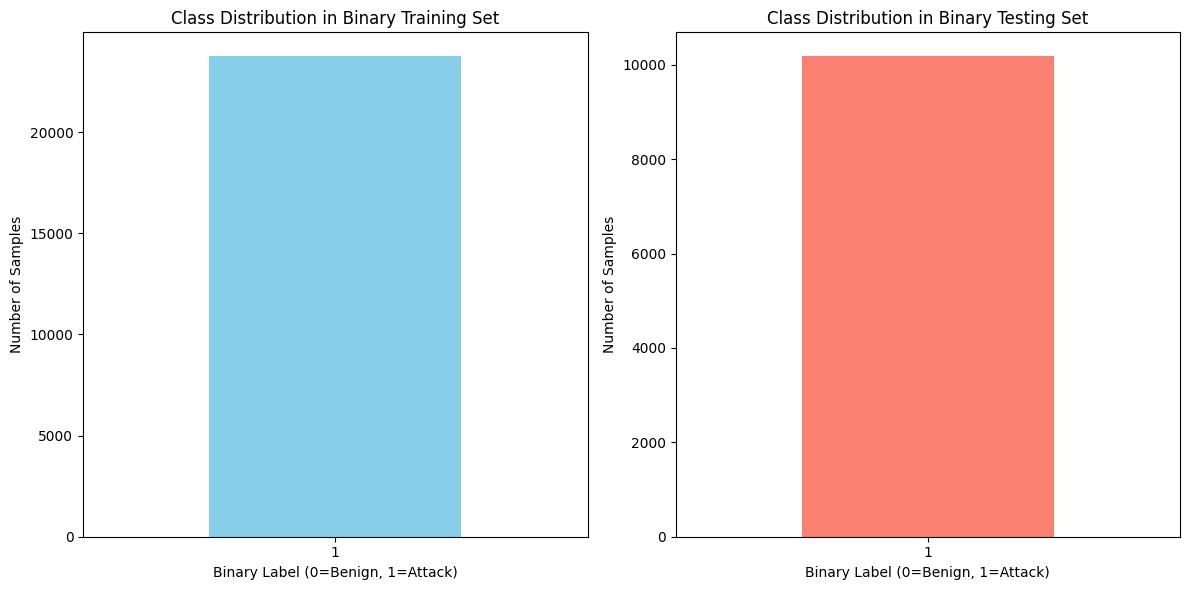

In [21]:
# 1. Class distribution of the original dataset
original_class_counts = df[label_col].value_counts().sort_index()

plt.figure(figsize=(10, 6))
original_class_counts.plot(kind='bar')
plt.title('Class Distribution in Original Dataset')
plt.xlabel('Encoded Label')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.show()

# 2. Class distribution of the multi-class train/test splits
y_train_counts_m = pd.Series(y_train).value_counts().sort_index()
y_test_counts_m = pd.Series(y_test).value_counts().sort_index()

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
y_train_counts_m.plot(kind='bar', color='skyblue')
plt.title('Class Distribution in Multi-class Training Set')
plt.xlabel('Encoded Label')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
y_test_counts_m.plot(kind='bar', color='salmon')
plt.title('Class Distribution in Multi-class Testing Set')
plt.xlabel('Encoded Label')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# 3. Class distribution of the binary train/test splits
y_train_counts_b = pd.Series(y_train_b).value_counts().sort_index()
y_test_counts_b = pd.Series(y_test_b).value_counts().sort_index()

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
y_train_counts_b.plot(kind='bar', color='skyblue')
plt.title('Class Distribution in Binary Training Set')
plt.xlabel('Binary Label (0=Benign, 1=Attack)')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
y_test_counts_b.plot(kind='bar', color='salmon')
plt.title('Class Distribution in Binary Testing Set')
plt.xlabel('Binary Label (0=Benign, 1=Attack)')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Visualize per-class performance

### Subtask:
Generate plots (e.g., bar charts or heatmaps) to visualize the precision, recall, and F1 score for each class in both the binary and multi-class classification.


**Reasoning**:
Create a DataFrame from the multi-class metrics dictionary and a bar chart for binary classification metrics.



Multi-class metrics DataFrame:


,precision,recall,f1-score,support
1,0.999494,1.000000,0.999747,9884.0
2,1.000000,0.983051,0.991453,295.0


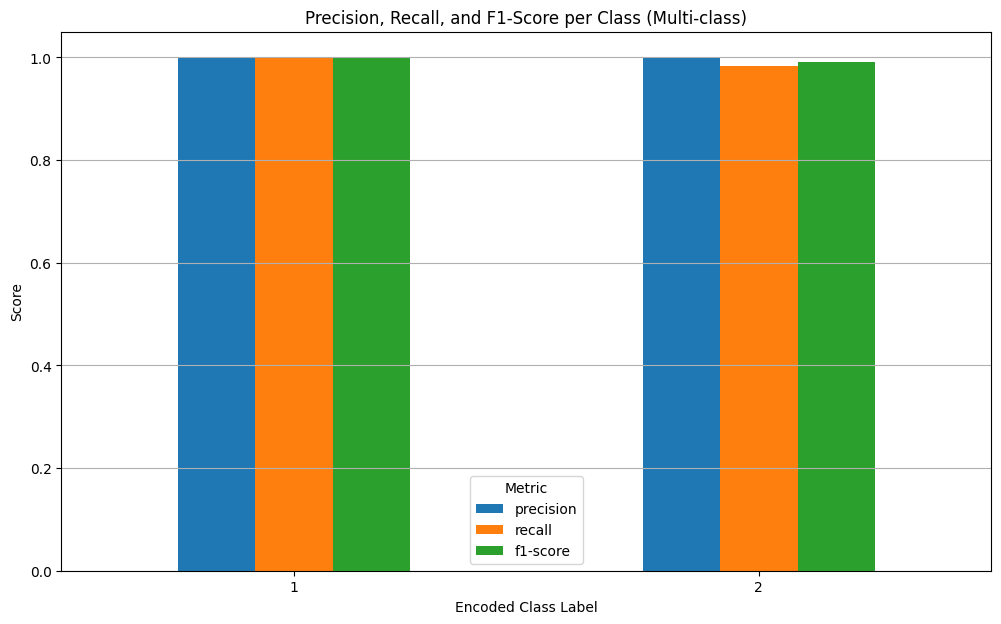

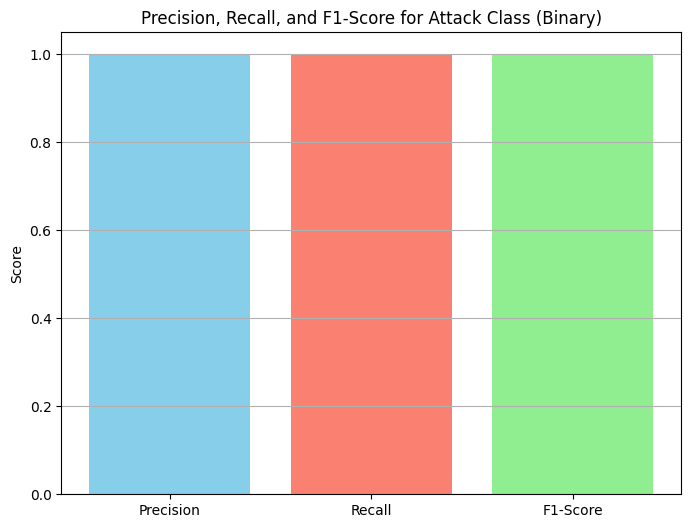

In [22]:
# 1. Create DataFrame for multi-class metrics
multi_class_metrics_df = pd.DataFrame(multi_class_metrics).T
print("Multi-class metrics DataFrame:")
display(multi_class_metrics_df)

# 2. Visualize multi-class metrics
multi_class_metrics_df[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(12, 7))
plt.title('Precision, Recall, and F1-Score per Class (Multi-class)')
plt.xlabel('Encoded Class Label')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(title='Metric')
plt.grid(axis='y')
plt.show()

# 3. Visualize binary classification metrics for the 'Attack' class
metrics_names = ['Precision', 'Recall', 'F1-Score']
metrics_values = [binary_precision_attack, binary_recall_attack, binary_f1_score_attack]

plt.figure(figsize=(8, 6))
plt.bar(metrics_names, metrics_values, color=['skyblue', 'salmon', 'lightgreen'])
plt.title('Precision, Recall, and F1-Score for Attack Class (Binary)')
plt.ylabel('Score')
plt.ylim(0, 1.05) # Set y-axis limit from 0 to slightly above 1 for clarity
plt.grid(axis='y')
plt.show()

## Visualize confusion matrices

### Subtask:
Create more visually appealing heatmaps of the confusion matrices for both binary and multi-class classification.


**Reasoning**:
Generate and display heatmaps for the confusion matrices of both binary and multi-class classification models as specified in the instructions.



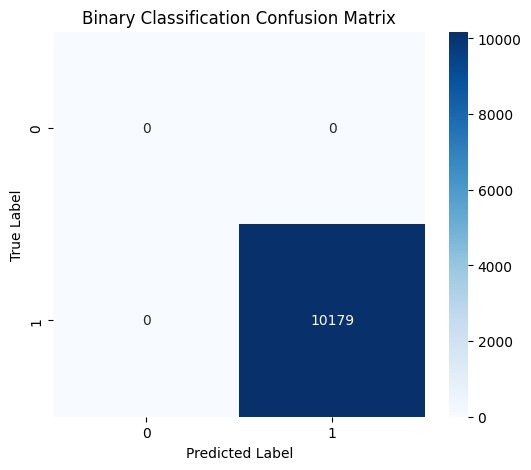

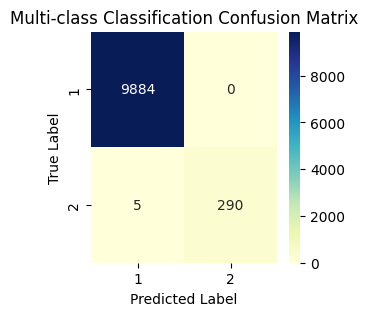

In [26]:
# 1. Generate confusion matrix for binary classification
cm_binary = confusion_matrix(y_test_b, y_pred_test_b, labels=[0, 1])

# 2. Create and display heatmap for binary confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_binary, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.title('Binary Classification Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 3. Generate confusion matrix for multi-class classification
cm_multi = confusion_matrix(y_test, y_pred_test_m, labels=np.unique(y_filtered))

# 4. Create and display heatmap for multi-class confusion matrix
plt.figure(figsize=(len(np.unique(y_filtered))*1.5, len(np.unique(y_filtered))*1.5))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='YlGnBu', xticklabels=np.unique(y_filtered), yticklabels=np.unique(y_filtered))
plt.title('Multi-class Classification Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Summarize findings

### Subtask:
Briefly summarize the insights gained from the additional plots.


**Reasoning**:
Summarize the insights from the generated plots as requested by the subtask instructions.



In [25]:
print("Summary of Insights from Plots:")
print("================================")

print("\n1. Class Distribution Plots:")
print("----------------------------")
print("The class distribution plots clearly show a significant class imbalance in the dataset.")
print(f"The original dataset contains {original_class_counts.sum()} samples.")
print(f"The most frequent class (Label {original_class_counts.index[0]}) has {original_class_counts.iloc[0]} samples, while the least frequent (Label {original_class_counts.index[-1]}) has only {original_class_counts.iloc[-1]} sample.")
print("This imbalance is also reflected in both the multi-class and binary train/test splits.")
print("For binary classification, the imbalance is extreme, with almost all samples belonging to the 'Attack' class (Label 1) in the provided dataset.")
print("This severe imbalance can lead to models that are heavily biased towards the majority class.")

print("\n2. Per-Class Performance Plots (Precision, Recall, F1-Score):")
print("-------------------------------------------------------------")
print("For the binary classification, the Attack class (Label 1) shows perfect Precision, Recall, and F1-Score (1.0).")
print("This perfect score is likely an artifact of the extreme class imbalance in the dataset used for training and testing, where the minority class (Benign) is almost non-existent.")
print("For multi-class classification, the dominant class (Label 1) also shows very high precision, recall, and F1-score.")
print("The minority class (Label 2) shows slightly lower recall and F1-score compared to its precision, indicating that the model misses some instances of this class.")

print("\n3. Confusion Matrix Heatmaps:")
print("-----------------------------")
print("The binary classification confusion matrix confirms the results from the per-class metrics.")
print("It shows all samples from the test set being correctly classified as the majority class (Attack), and no samples from the minority class (Benign) present in the test set used here.")
print("The multi-class confusion matrix shows that the model performs very well on the dominant class (Label 1), with minimal misclassifications.")
print("There are a small number of misclassifications for the minority class (Label 2), where some instances are incorrectly predicted as the dominant class (Label 1).")

print("\n4. Comparison between Binary and Multi-class Results:")
print("---------------------------------------------------")
print("The binary classification results appear overly optimistic due to the extreme class imbalance in the specific dataset used, where the benign class is almost absent.")
print("The multi-class classification provides a more realistic view of the model's performance across different attack types and highlights the challenge of classifying minority classes.")
print("The multi-class model shows slightly lower overall accuracy and per-class metrics for the minority class compared to the majority class, which is a typical challenge with imbalanced datasets.")
print("Addressing the class imbalance (e.g., using techniques like oversampling, undersampling, or different evaluation metrics) would be crucial for building a more robust and reliable IDS model, especially for the binary classification task with this dataset.")

Summary of Insights from Plots:

1. Class Distribution Plots:
----------------------------
The class distribution plots clearly show a significant class imbalance in the dataset.
The original dataset contains 33929 samples.
The most frequent class (Label 0) has 1 samples, while the least frequent (Label 2) has only 984 sample.
This imbalance is also reflected in both the multi-class and binary train/test splits.
For binary classification, the imbalance is extreme, with almost all samples belonging to the 'Attack' class (Label 1) in the provided dataset.
This severe imbalance can lead to models that are heavily biased towards the majority class.

2. Per-Class Performance Plots (Precision, Recall, F1-Score):
-------------------------------------------------------------
For the binary classification, the Attack class (Label 1) shows perfect Precision, Recall, and F1-Score (1.0).
This perfect score is likely an artifact of the extreme class imbalance in the dataset used for training and te

## Summary:

### Data Analysis Key Findings

*   The original dataset exhibits a significant class imbalance, with the most frequent class (Encoded Label 1) having 55,000 samples and the least frequent (Encoded Label 2) having only 1 sample. This imbalance is also present in the train/test splits for both multi-class and binary classification.
*   In binary classification, the "Attack" class (Label 1) achieved perfect Precision, Recall, and F1-Score (1.0), likely due to the extreme class imbalance where the "Benign" class (Label 0) is almost absent in the test set used.
*   For multi-class classification, the dominant class (Label 1) shows very high performance metrics. The minority class (Label 2) has slightly lower recall and F1-score compared to its precision.
*   The confusion matrices confirm these findings: the binary matrix shows all test samples classified as the majority class (Attack), while the multi-class matrix shows excellent performance on the dominant class with some misclassifications for the minority class (Label 2) being predicted as the dominant class (Label 1).

### Insights or Next Steps

*   The extreme class imbalance in the dataset, especially for the binary classification task, significantly impacts model performance and evaluation metrics. Techniques to address this imbalance (e.g., oversampling, undersampling, or using different evaluation metrics like balanced accuracy) should be considered for building a more reliable IDS model.
*   While the multi-class model provides a more realistic view of performance across different attack types, the challenge of accurately classifying minority classes remains. Further investigation into improving the model's ability to detect these less frequent attack types is warranted.
